In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

In [4]:
df = pd.read_csv("dataset/dataset.csv")

In [4]:
df.head()
df.info()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 6417106 entries, 0 to 6417105
Data columns (total 5 columns):
 #   Column        Dtype
---  ------        -----
 0   app_id        int64
 1   app_name      str  
 2   review_text   str  
 3   review_score  int64
 4   review_votes  int64
dtypes: int64(3), str(2)
memory usage: 244.8 MB


Index(['app_id', 'app_name', 'review_text', 'review_score', 'review_votes'], dtype='str')

In [5]:
# Use a smaller sample so the notebook runs faster
df_sample = df.sample(n=50000, random_state=42)

df_sample.shape

(50000, 5)

In [6]:
df_sample.head()

,app_id,app_name,review_text,review_score,review_votes
301327,12210,Grand Theft Auto IV: The Complete Edition,Best bowling simulator 2014 10/10 It has good ...,1,1
1662500,226320,Marvel Heroes Omega,Marvel characters? Check. Tons of loot? Check....,1,0
2061157,236450,PAC-MAN Championship Edition DX+,This game while its not the original is defina...,1,0
1171799,218620,PAYDAY 2,"This game ♥♥♥♥ing awesome ,You can be professi...",1,0
1450080,221640,Super Hexagon,"If you are high, play this game. 420/420 would...",1,0


In [7]:
df_sample["review_score"].value_counts()

review_score
 1    41021
-1     8979
Name: count, dtype: int64

In [8]:
df_sample.isnull().sum()

app_id             0
app_name        1436
review_text       58
review_score       0
review_votes       0
dtype: int64

In [9]:
# Remove rows with missing review text
df_sample = df_sample.dropna(subset=["review_text"])

# Remove duplicates
df_sample = df_sample.drop_duplicates(subset=["review_text"])

df_sample.shape

(41319, 5)

In [10]:
df_sample["review_text"].iloc[0]

'Best bowling simulator 2014 10/10 It has good storyline too.'

In [11]:
import re

def clean_text(text):
    text = str(text).lower()                     # lowercase
    text = re.sub(r"http\S+|www\S+", " ", text)  # remove links
    text = re.sub(r"[^a-zA-Z\s]", " ", text)     # remove numbers/punctuation
    text = re.sub(r"\s+", " ", text).strip()     # remove extra spaces
    return text

df_sample["clean_review"] = df_sample["review_text"].apply(clean_text)

df_sample[["review_text", "clean_review"]].head()

,review_text,clean_review
301327,Best bowling simulator 2014 10/10 It has good ...,best bowling simulator it has good storyline too
1662500,Marvel characters? Check. Tons of loot? Check....,marvel characters check tons of loot check ton...
2061157,This game while its not the original is defina...,this game while its not the original is defina...
1171799,"This game ♥♥♥♥ing awesome ,You can be professi...",this game ing awesome you can be professional ...
1450080,"If you are high, play this game. 420/420 would...",if you are high play this game would dank


In [12]:
df_sample["sentiment"] = df_sample["review_score"].map({1: 1, -1: 0})

df_sample[["review_score", "sentiment"]].head()

,review_score,sentiment
301327,1,1
1662500,1,1
2061157,1,1
1171799,1,1
1450080,1,1


In [13]:
df_sample["sentiment"].value_counts()

sentiment
1    34037
0     7282
Name: count, dtype: int64

In [14]:
X = df_sample["clean_review"]
y = df_sample["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("Training labels:")
print(y_train.value_counts())
print("Testing labels:")
print(y_test.value_counts())

Training set size: (33055,)
Testing set size: (8264,)
Training labels:
sentiment
1    27229
0     5826
Name: count, dtype: int64
Testing labels:
sentiment
1    6808
0    1456
Name: count, dtype: int64


In [15]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF training shape:", X_train_tfidf.shape)
print("TF-IDF testing shape:", X_test_tfidf.shape)

TF-IDF training shape: (33055, 5000)
TF-IDF testing shape: (8264, 5000)


In [16]:
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_predictions = nb_model.predict(X_test_tfidf)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_predictions))
print(classification_report(y_test, nb_predictions))

Naive Bayes Accuracy: 0.8520087124878993
              precision    recall  f1-score   support

           0       0.81      0.21      0.33      1456
           1       0.85      0.99      0.92      6808

    accuracy                           0.85      8264
   macro avg       0.83      0.60      0.62      8264
weighted avg       0.85      0.85      0.81      8264



In [17]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

lr_predictions = lr_model.predict(X_test_tfidf)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_predictions))
print(classification_report(y_test, lr_predictions))

Logistic Regression Accuracy: 0.8754840271055179
              precision    recall  f1-score   support

           0       0.76      0.42      0.55      1456
           1       0.89      0.97      0.93      6808

    accuracy                           0.88      8264
   macro avg       0.83      0.70      0.74      8264
weighted avg       0.87      0.88      0.86      8264



In [18]:
svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)

svm_predictions = svm_model.predict(X_test_tfidf)

print("Linear SVM Accuracy:", accuracy_score(y_test, svm_predictions))
print(classification_report(y_test, svm_predictions))

Linear SVM Accuracy: 0.8753630203291385
              precision    recall  f1-score   support

           0       0.69      0.53      0.60      1456
           1       0.90      0.95      0.93      6808

    accuracy                           0.88      8264
   macro avg       0.80      0.74      0.76      8264
weighted avg       0.87      0.88      0.87      8264



In [19]:
results = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression", "Linear SVM"],
    "Accuracy": [
        accuracy_score(y_test, nb_predictions),
        accuracy_score(y_test, lr_predictions),
        accuracy_score(y_test, svm_predictions)
    ],
    "Negative Precision": [0.81, 0.76, 0.69],
    "Negative Recall": [0.21, 0.42, 0.53],
    "Negative F1-score": [0.33, 0.55, 0.60]
})

results

,Model,Accuracy,Negative Precision,Negative Recall,Negative F1-score
0,Naive Bayes,0.852009,0.81,0.21,0.33
1,Logistic Regression,0.875484,0.76,0.42,0.55
2,Linear SVM,0.875363,0.69,0.53,0.60


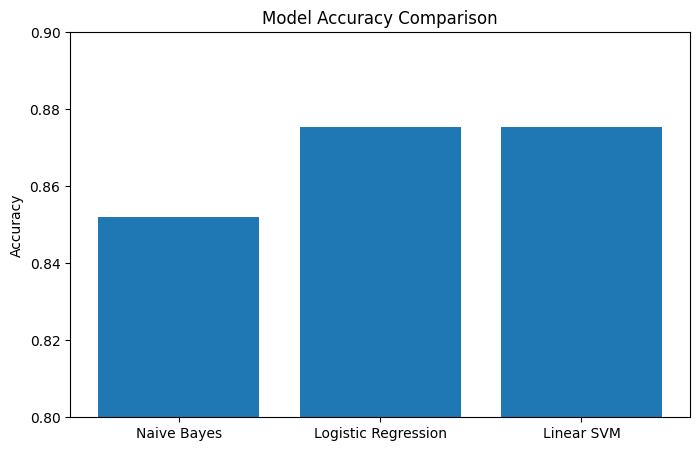

In [20]:
plt.figure(figsize=(8, 5))
plt.bar(results["Model"], results["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.8, 0.9)
plt.show()

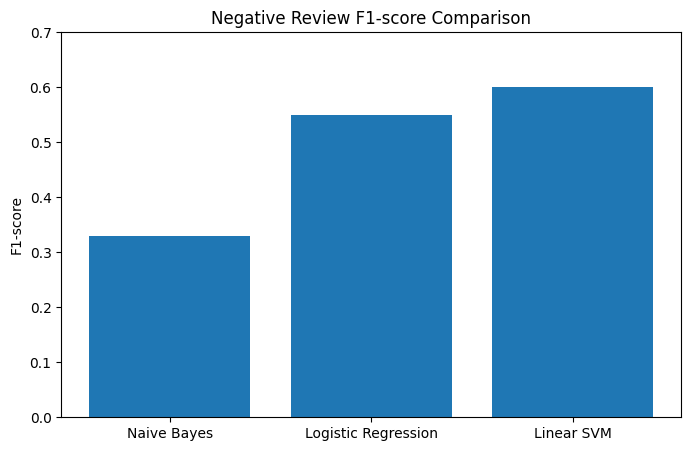

In [21]:
plt.figure(figsize=(8, 5))
plt.bar(results["Model"], results["Negative F1-score"])
plt.title("Negative Review F1-score Comparison")
plt.ylabel("F1-score")
plt.ylim(0, 0.7)
plt.show()

In [22]:
cm = confusion_matrix(y_test, svm_predictions)

print(cm)

[[ 765  691]
 [ 339 6469]]


In [23]:
cm_df = pd.DataFrame(
    cm,
    index=["Actual Negative", "Actual Positive"],
    columns=["Predicted Negative", "Predicted Positive"]
)

cm_df

,Predicted Negative,Predicted Positive
Actual Negative,765,691
Actual Positive,339,6469


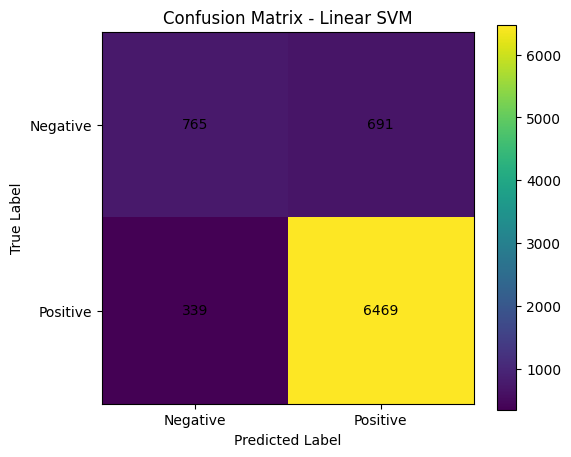

In [24]:
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix - Linear SVM")
plt.colorbar()

tick_marks = np.arange(2)
plt.xticks(tick_marks, ["Negative", "Positive"])
plt.yticks(tick_marks, ["Negative", "Positive"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [25]:
df_sample.to_csv("cleaned_steam_reviews_sample.csv", index=False)
results.to_csv("model_results.csv", index=False)

print("Files saved successfully")

Files saved successfully
